In [1]:
from dataLoader import SignLanguageDataLoader, load_data_only, quick_load, load_data_efficient
import numpy as np
from pathlib import Path

print("="*60)
print("METHOD 1: Load data only (no masks)")
print("="*60)

# Path to your data directory
dataset_path = r"D:\GP\cleaned_landmarks_147words\cleaned_landmarks_100words"

# Load data and labels only (no masks)
data, labels = load_data_only(dataset_path)

print(f"✅ Data loaded successfully!")
print(f"   Data shape: {len(data)} samples")
print(f"   Labels shape: {len(labels)}")
print(f"   Unique classes: {len(np.unique(labels))}")
print(f"   First sample shape: {data[0].shape}")

METHOD 1: Load data only (no masks)
📦 Loading metadata from cache: D:\GP\cleaned_landmarks_147words\cleaned_landmarks_100words\.cache\metadata_with_masks.pkl
✅ Loaded metadata for 4216 files


Loading data: 100%|██████████| 4216/4216 [00:05<00:00, 754.20it/s]

✅ Data loaded successfully!
   Data shape: 4216 samples
   Labels shape: 4216
   Unique classes: 147
   First sample shape: (79, 438)


In [8]:
# ============================================================
# TEST EACH AUGMENTATION FEATURE ON A SINGLE SAMPLE
# ============================================================

from Augemnt import MemoryEfficientAugmenter
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')



# ============================================================
# MAIN TEST
# ============================================================

print("="*60)
print("🧪 TESTING AUGMENTATION FEATURES ON A SINGLE SAMPLE")
print("="*60)

# ============================================================
# 1. LOAD A SINGLE SAMPLE FROM YOUR DATA
# ============================================================

print("\n📂 Loading a single sample...")

# Your data is already loaded as 'data' and 'labels'
sample_idx = 2000  # Change this to test different samples
original_sequence = data[sample_idx].astype(np.float32)
original_label = labels[sample_idx]

print(f"Sample index: {sample_idx}")
print(f"Label: {original_label}")
print(f"Original shape: {original_sequence.shape}")
print(f"Original dtype: {original_sequence.dtype}")


# ============================================================
# 2. INITIALIZE AUGMENTER
# ============================================================

augmenter = MemoryEfficientAugmenter()
print("\n" + "="*60)
print("🔧 Augmenter initialized")
print("="*60)

# ============================================================
# 3. TEST 1: SPEED VARIANCE (FASTER)
# ============================================================

print("\n" + "="*60)
print("🚀 TEST 1: Speed Variance - FASTER")
print("="*60)

augmented_faster = augmenter.apply_speed_variance(
    original_sequence, 
    mode='faster'
)

print(f"   Original length: {len(original_sequence)} → New length: {len(augmented_faster)}")

# ============================================================
# 4. TEST 2: SPEED VARIANCE (SLOWER)
# ============================================================

print("\n" + "="*60)
print("🐢 TEST 2: Speed Variance - SLOWER")
print("="*60)

augmented_slower = augmenter.apply_speed_variance(
    original_sequence, 
    mode='slower'
)

print(f"   Original length: {len(original_sequence)} → New length: {len(augmented_slower)}")

# ============================================================
# 5. TEST 3: SPEED VARIANCE (BALANCED)
# ============================================================

print("\n" + "="*60)
print("⚖️ TEST 3: Speed Variance - BALANCED")
print("="*60)

augmented_balanced = augmenter.apply_speed_variance(
    original_sequence, 
    mode='balanced'
)

print(f"   Original length: {len(original_sequence)} → New length: {len(augmented_balanced)}")

# ============================================================
# 6. TEST 4: HAND SHIFTING (Different shifts)
# ============================================================

print("\n" + "="*60)
print("🖐️ TEST 4: Hand Shifting")
print("="*60)

# Test with different shift amounts
shift_amounts = [0.01, 0.03, 0.05]
for shift in shift_amounts:
    # Temporarily change max_shift
    original_max_shift = augmenter.apply_hand_shift.__defaults__[0] if augmenter.apply_hand_shift.__defaults__ else 0.03
    shifted = augmenter.apply_hand_shift(original_sequence, max_shift=shift)

# ============================================================
# 7. TEST 5: HAND SCALING
# ============================================================

print("\n" + "="*60)
print("📏 TEST 5: Hand Scaling")
print("="*60)

# Test with different scale changes
scale_changes = [0.02, 0.04, 0.6]
for scale in scale_changes:
    scaled = augmenter.apply_hand_scale(original_sequence, max_scale_change=scale)
   


# ============================================================
# 8. TEST 6: HAND ROTATION
# ============================================================

print("\n" + "="*60)
print("🔄 TEST 6: Hand Rotation")
print("="*60)

# Test with different angles
angles = [3.0, 5.0, 8.0, 10.0]
for angle in angles:
    # Temporarily change max_angle
    rotated = augmenter.apply_hand_rotation(original_sequence, max_angle=angle)



🧪 TESTING AUGMENTATION FEATURES ON A SINGLE SAMPLE

📂 Loading a single sample...
Sample index: 2000
Label: APRIL
Original shape: (106, 438)
Original dtype: float32

🔧 Augmenter initialized

🚀 TEST 1: Speed Variance - FASTER
   Original length: 106 → New length: 96

🐢 TEST 2: Speed Variance - SLOWER
   Original length: 106 → New length: 122

⚖️ TEST 3: Speed Variance - BALANCED
   Original length: 106 → New length: 91

🖐️ TEST 4: Hand Shifting

📏 TEST 5: Hand Scaling

🔄 TEST 6: Hand Rotation


In [11]:
from RenderAugm import display_original_vs_augmented
display_original_vs_augmented(original_sequence,shifted)

Original frames: 106, Augmented frames: 106

🎬 Rendering Side-by-Side Comparison
   Original Sample: 106 frames
   Augmented Sample: 106 frames
   Displaying 106 frames total
   Controls: 'q' to quit, 'p' to pause, 's' to save frame
Paused. Press any key to resume...
Paused. Press any key to resume...
Paused. Press any key to resume...

✅ Comparison complete!


In [13]:
# ============================================================
# APPLY AUGMENTATION TO YOUR LOADED DATA (FIXED)
# ============================================================

from Augemnt import augment_dataset, simple_augment
import numpy as np
from collections import Counter
import gc

# ============================================================
# FIXED AUGMENTATION FUNCTION THAT HANDLES INHOMOGENEOUS SHAPES
# ============================================================

def apply_augmentation_to_list(data, labels, augmentations_per_sample=2, augmentation_types=['shift', 'scale'], verbose=True):
    """
    Apply augmentation directly to list of arrays without converting to 3D first
    """
    from Augemnt import MemoryEfficientAugmenter
    
    augmenter = MemoryEfficientAugmenter()
    
    augmented_data = []
    augmented_labels = []
    
    num_samples = len(data)
    
    if verbose:
        print(f"Processing {num_samples} samples...")
    
    for i in range(num_samples):
        sample = data[i]
        label = labels[i]
        
        # Ensure sample is float32
        if not isinstance(sample, np.ndarray):
            sample = np.array(sample, dtype=np.float32)
        else:
            sample = sample.astype(np.float32)
        
        # Add original
        augmented_data.append(sample)
        augmented_labels.append(label)
        
        # Create augmentations
        for aug_idx in range(augmentations_per_sample):
            # Randomly select augmentation types
            if len(augmentation_types) > 2:
                import random
                selected = random.sample(augmentation_types, random.randint(1, 2))
            else:
                selected = augmentation_types
            
            # Apply augmentation
            aug_sample = augmenter.augment_single(sample, selected)
            augmented_data.append(aug_sample)
            augmented_labels.append(label)
        
        # Progress
        if verbose and (i + 1) % 500 == 0:
            print(f"   Processed {i+1}/{num_samples} samples")
        
        # Clear memory periodically
        if (i + 1) % 1000 == 0:
            gc.collect()
    
    # Keep as list (don't convert to 3D array to avoid inhomogeneous issues)
    if verbose:
        print(f"\n📊 Augmentation Stats:")
        print(f"   Original samples: {num_samples}")
        print(f"   Augmented samples: {len(augmented_data)}")
        print(f"   Augmentation factor: {len(augmented_data)/num_samples:.1f}x")
    
    return augmented_data, np.array(augmented_labels)

# ============================================================
# STEP 1: CHECK YOUR DATA FORMAT FIRST
# ============================================================

print("="*60)
print("STEP 1: Checking Data Format")
print("="*60)

print(f"Data type: {type(data)}")
print(f"Data length: {len(data)}")
print(f"First sample type: {type(data[0])}")
print(f"First sample shape: {data[0].shape}")
print(f"First sample dtype: {data[0].dtype}")
print(f"Labels type: {type(labels)}")
print(f"Labels length: {len(labels)}")

# ============================================================
# STEP 2: APPLY AUGMENTATION DIRECTLY (NO CONVERSION NEEDED)
# ============================================================

print("\n" + "="*60)
print("STEP 2: Applying Augmentation")
print("="*60)

# Choose augmentation type and count
AUGMENTATIONS_PER_SAMPLE = 2
AUGMENTATION_TYPES = ['shift', 'scale']  # Use only shift and scale (safe)

print(f"Augmentations per sample: {AUGMENTATIONS_PER_SAMPLE}")
print(f"Augmentation types: {AUGMENTATION_TYPES}")
print(f"Preserve original: True")

print("\n📦 Running augmentation directly on list...")
X_augmented, y_augmented = apply_augmentation_to_list(
    data=data,
    labels=labels,
    augmentations_per_sample=AUGMENTATIONS_PER_SAMPLE,
    augmentation_types=AUGMENTATION_TYPES,
    verbose=True
)

print(f"\n✅ Augmentation complete!")
print(f"   Original samples: {len(data)}")
print(f"   Augmented samples: {len(X_augmented)}")
print(f"   Augmentation factor: {len(X_augmented)/len(data):.1f}x")

# ============================================================
# STEP 3: CHECK RESULTS
# ============================================================

print("\n" + "="*60)
print("STEP 3: Checking Results")
print("="*60)

print(f"Augmented data length: {len(X_augmented)}")
print(f"Augmented labels length: {len(y_augmented)}")
print(f"First augmented sample shape: {X_augmented[0].shape}")
print(f"First augmented sample dtype: {X_augmented[0].dtype}")

# Check class distribution after augmentation
augmented_class_counts = Counter(y_augmented)
print(f"\n📊 Class Distribution After Augmentation:")
print(f"   Total classes: {len(augmented_class_counts)}")
print(f"   Min samples per class: {min(augmented_class_counts.values())}")
print(f"   Max samples per class: {max(augmented_class_counts.values())}")
print(f"   Mean samples per class: {np.mean(list(augmented_class_counts.values())):.1f}")





STEP 1: Checking Data Format
Data type: <class 'numpy.ndarray'>
Data length: 4216
First sample type: <class 'numpy.ndarray'>
First sample shape: (79, 438)
First sample dtype: float64
Labels type: <class 'numpy.ndarray'>
Labels length: 4216

STEP 2: Applying Augmentation
Augmentations per sample: 2
Augmentation types: ['shift', 'scale']
Preserve original: True

📦 Running augmentation directly on list...
Processing 4216 samples...
   Processed 500/4216 samples
   Processed 1000/4216 samples
   Processed 1500/4216 samples
   Processed 2000/4216 samples
   Processed 2500/4216 samples
   Processed 3000/4216 samples
   Processed 3500/4216 samples
   Processed 4000/4216 samples

📊 Augmentation Stats:
   Original samples: 4216
   Augmented samples: 12648
   Augmentation factor: 3.0x

✅ Augmentation complete!
   Original samples: 4216
   Augmented samples: 12648
   Augmentation factor: 3.0x

STEP 3: Checking Results
Augmented data length: 12648
Augmented labels length: 12648
First augmented sam


📊 STEP 1: Analyzing Class Distribution
📊 CURRENT CLASS DISTRIBUTION ANALYSIS
Total classes: 147
Total samples: 12,648
Min samples: 51
Max samples: 183
Mean samples: 86.0
Std samples: 14.1
Median samples: 84.0
Imbalance ratio (max/min): 3.6
⚠️ Significant imbalance detected!

⚖️ STEP 2: Choose Balancing Method
1. Weighted Sampler (No data modification - Recommended)
2. Oversample Rare Classes (Duplicates data)
3. Undersample Frequent Classes (Removes data)
4. Smart Balancing (Oversamples rare, undersamples frequent)

✅ OPTION 4: Smart Balancing (Recommended)

📊 SMART CLASS BALANCING
Current mean: 86.0
Target mean: 86.0
Oversample threshold: < 60.2
Undersample threshold: > 129.1

📊 Balancing Results:
   Oversampled classes: 1
      YOU: 51 → 86 (+35)

   Undersampled classes: 2
      ARM: 183 → 103 (-80)
      WANT: 183 → 103 (-80)

   Kept classes: 144

✅ Smart balancing complete!
   Original samples: 12,648
   Balanced samples: 12,523

✅ Smart balancing complete!
   Original: 12648 sa

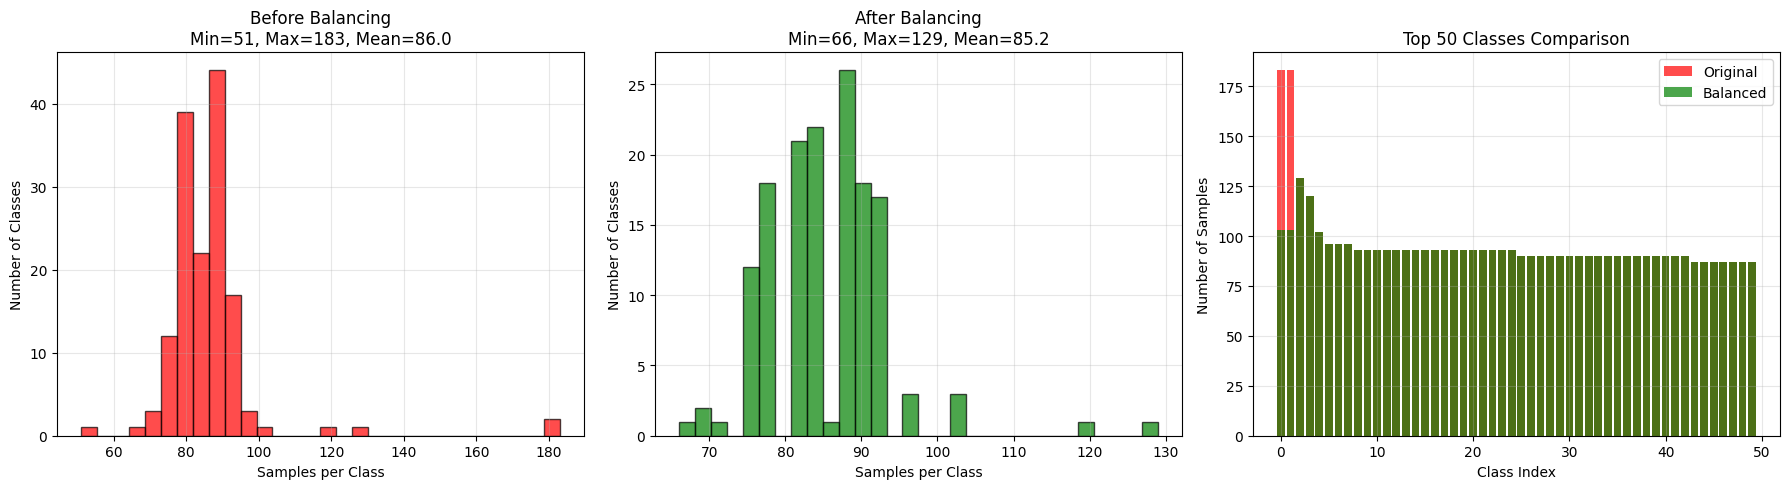

📊 Saved: class_balancing_results.png


In [14]:
# ============================================================
# APPLY CLASS BALANCING TO AUGMENTED DATA USING EXISTING FUNCTIONS
# ============================================================

from BalanceData import (
    analyze_class_balance, 
    create_weighted_sampler,
    oversample_rare_classes,
    undersample_frequent_classes,
    smart_class_balancing,
    visualize_balancing,
    create_balanced_dataloader
)
import numpy as np
from collections import Counter
import torch

# ============================================================
# STEP 1: Analyze Current Class Distribution
# ============================================================

print("\n" + "="*60)
print("📊 STEP 1: Analyzing Class Distribution")
print("="*60)

# Analyze your augmented data
class_counts = analyze_class_balance(y_augmented)

# ============================================================
# STEP 2: Choose Balancing Method
# ============================================================

print("\n" + "="*60)
print("⚖️ STEP 2: Choose Balancing Method")
print("="*60)
print("1. Weighted Sampler (No data modification - Recommended)")
print("2. Oversample Rare Classes (Duplicates data)")
print("3. Undersample Frequent Classes (Removes data)")
print("4. Smart Balancing (Oversamples rare, undersamples frequent)")
print("="*60)


print("\n✅ OPTION 4: Smart Balancing (Recommended)")
print("="*60)

# For smart balancing, we need to convert to list format first
X_list = X_augmented  # Already a list
y_list = y_augmented.tolist() if isinstance(y_augmented, np.ndarray) else list(y_augmented)

# Apply smart balancing
balanced_data, balanced_labels, balancing_stats = smart_class_balancing(
    data=X_list,
    labels=y_list,
    target_mean=None,  # Auto-calculate
    oversample_threshold=0.7,  # Oversample classes below 70% of mean
    undersample_threshold=1.5,  # Undersample classes above 150% of mean
    use_augmentation=False,
    augmenter=None
)

print(f"\n✅ Smart balancing complete!")
print(f"   Original: {len(X_list)} samples")
print(f"   Balanced: {len(balanced_data)} samples")

# Convert balanced data to 3D array
max_frames = max(seq.shape[0] for seq in balanced_data)
feature_dim = balanced_data[0].shape[1]

X_balanced_padded = []
for seq in balanced_data:
    if seq.shape[0] < max_frames:
        pad = np.zeros((max_frames - seq.shape[0], feature_dim), dtype=np.float32)
        padded = np.vstack([seq, pad])
    else:
        padded = seq[:max_frames]
    X_balanced_padded.append(padded.astype(np.float32))

X_balanced_3d = np.array(X_balanced_padded, dtype=np.float32)
y_balanced = np.array(balanced_labels)

print(f"✅ Final balanced shape: {X_balanced_3d.shape}")

# Visualize balancing results
visualize_balancing(y_augmented, y_balanced)



In [19]:
balanced_data[1000].shape

(80, 438)

In [20]:
# ============================================================
# FIXED LENGTH PADDING / TRUNCATION FOR BALANCED DATA
# ============================================================

import numpy as np
from collections import Counter
from tqdm import tqdm
import pickle

# ============================================================
# FUNCTION: PAD OR TRUNCATE SEQUENCES TO FIXED LENGTH
# ============================================================

def pad_or_truncate_sequence(sequence, target_length=125, feature_dim=438):
    """
    Pad or truncate a single sequence to target length
    
    Args:
        sequence: numpy array of shape (frames, features)
        target_length: Desired number of frames
        feature_dim: Desired feature dimension
    
    Returns:
        Padded/truncated sequence of shape (target_length, feature_dim)
    """
    current_frames = sequence.shape[0]
    current_features = sequence.shape[1] if sequence.ndim > 1 else 1
    
    # Handle feature dimension
    if current_features != feature_dim:
        if current_features > feature_dim:
            sequence = sequence[:, :feature_dim]
        else:
            pad = np.zeros((current_frames, feature_dim - current_features), dtype=np.float32)
            sequence = np.hstack([sequence, pad])
    
    # Handle frames (pad or truncate)
    if current_frames >= target_length:
        return sequence[:target_length].astype(np.float32)
    else:
        pad = np.zeros((target_length - current_frames, feature_dim), dtype=np.float32)
        return np.vstack([sequence, pad]).astype(np.float32)


def pad_sequences_to_fixed_length(data, target_length=125, feature_dim=438, verbose=True):
    """
    Pad or truncate all sequences to fixed length
    
    Args:
        data: List of numpy arrays or numpy array of shape (num_samples, frames, features)
        target_length: Desired number of frames
        feature_dim: Desired feature dimension
        verbose: Print progress
    
    Returns:
        Padded data as numpy array of shape (num_samples, target_length, feature_dim)
    """
    if verbose:
        print("="*60)
        print("📏 PADDING/TRUNCATING SEQUENCES TO FIXED LENGTH")
        print("="*60)
        print(f"Target length: {target_length} frames")
        print(f"Feature dimension: {feature_dim}")
    
    # Check input type
    if isinstance(data, np.ndarray) and data.ndim == 3:
        # Already a 3D array
        num_samples = data.shape[0]
        
        if verbose:
            print(f"Input shape: {data.shape}")
        
        padded_data = []
        for i in tqdm(range(num_samples), desc="Processing", disable=not verbose):
            seq = data[i]
            padded = pad_or_truncate_sequence(seq, target_length, feature_dim)
            padded_data.append(padded)
        
        result = np.array(padded_data, dtype=np.float32)
        
    elif isinstance(data, (list, np.ndarray)):
        # List of arrays
        num_samples = len(data)
        
        if verbose:
            print(f"Input: List of {num_samples} sequences")
            if num_samples > 0:
                print(f"First sequence shape: {data[0].shape}")
        
        padded_data = []
        for i in tqdm(range(num_samples), desc="Processing", disable=not verbose):
            seq = data[i]
            padded = pad_or_truncate_sequence(seq, target_length, feature_dim)
            padded_data.append(padded)
        
        result = np.array(padded_data, dtype=np.float32)
    else:
        raise ValueError(f"Unsupported data type: {type(data)}")
    
    if verbose:
        print(f"\n✅ Padding complete!")
        print(f"   Output shape: {result.shape}")
        print(f"   Data type: {result.dtype}")
        print("="*60)
    
    return result


def analyze_frame_lengths(data, verbose=True):
    """
    Analyze frame length distribution of sequences
    
    Args:
        data: List of numpy arrays or numpy array of shape (num_samples, frames, features)
        verbose: Print results
    
    Returns:
        Dictionary with frame length statistics
    """
    if isinstance(data, np.ndarray) and data.ndim == 3:
        lengths = [data[i].shape[0] for i in range(data.shape[0])]
    else:
        lengths = [seq.shape[0] for seq in data]
    
    stats = {
        'min': min(lengths),
        'max': max(lengths),
        'mean': np.mean(lengths),
        'std': np.std(lengths),
        'median': np.median(lengths),
        'unique_lengths': len(set(lengths))
    }
    
    if verbose:
        print("="*60)
        print("📊 FRAME LENGTH ANALYSIS")
        print("="*60)
        print(f"Number of sequences: {len(lengths)}")
        print(f"Min frames: {stats['min']}")
        print(f"Max frames: {stats['max']}")
        print(f"Mean frames: {stats['mean']:.1f}")
        print(f"Std frames: {stats['std']:.1f}")
        print(f"Median frames: {stats['median']:.1f}")
        print(f"Unique lengths: {stats['unique_lengths']}")
        
        # Show distribution of lengths
        length_counts = Counter(lengths)
        print(f"\n📈 Length distribution (top 10):")
        for length, count in sorted(length_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"   {length} frames: {count} sequences")
        print("="*60)
    
    return stats


def get_optimal_target_length(data, percentile=95):
    """
    Determine optimal target length based on percentile of frame lengths
    
    Args:
        data: List of numpy arrays
        percentile: Percentile to use (default 95)
    
    Returns:
        Optimal target length
    """
    if isinstance(data, np.ndarray) and data.ndim == 3:
        lengths = [data[i].shape[0] for i in range(data.shape[0])]
    else:
        lengths = [seq.shape[0] for seq in data]
    
    target = int(np.percentile(lengths, percentile))
    print(f"Recommended target length ({percentile}th percentile): {target} frames")
    print(f"  This will keep {100-percentile}% of sequences truncated, {percentile}% padded")
    
    return target


# ============================================================
# APPLY TO YOUR BALANCED DATA
# ============================================================

print("\n" + "="*60)
print("🎯 APPLYING FIXED LENGTH PADDING TO BALANCED DATA")
print("="*60)

# Check if balanced_data exists
try:
    if 'balanced_data' in locals() or 'balanced_data' in globals():
        print("✅ Balanced data found!")
        print(f"   Type: {type(balanced_data)}")
        print(f"   Length: {len(balanced_data)}")
        if len(balanced_data) > 0:
            print(f"   First sample shape: {balanced_data[0].shape}")
    else:
        print("❌ balanced_data not found! Please run class balancing first.")
        exit()
except NameError:
    print("❌ balanced_data not found! Please run class balancing first.")
    exit()

# Check if balanced_labels exists
try:
    if 'balanced_labels' in locals() or 'balanced_labels' in globals():
        print(f"✅ Balanced labels found! Length: {len(balanced_labels)}")
    else:
        print("❌ balanced_labels not found!")
        exit()
except NameError:
    print("❌ balanced_labels not found!")
    exit()

# ============================================================
# STEP 1: Analyze current frame lengths
# ============================================================

print("\n📊 STEP 1: Analyzing current frame lengths of balanced data")
print("="*60)

frame_stats = analyze_frame_lengths(balanced_data, verbose=True)

# ============================================================
# STEP 2: Choose target length
# ============================================================

print("\n📏 STEP 2: Choosing target length")
print("="*60)

# Option A: Use max frames (preserves all data)
TARGET_LENGTH_MAX = frame_stats['max']
print(f"Option A - Max frames: {TARGET_LENGTH_MAX}")

# Option B: Use percentile (balance between memory and preservation)
TARGET_LENGTH_PERCENTILE = get_optimal_target_length(balanced_data, percentile=95)

# Option C: Use standard length (125 is typical for sign language)
TARGET_LENGTH_STANDARD = 125
print(f"Option C - Standard length: {TARGET_LENGTH_STANDARD}")

# Choose target length (change as needed)
# Recommended: Use 125 for compatibility with TCN model
TARGET_LENGTH = TARGET_LENGTH_STANDARD  # Change to TARGET_LENGTH_MAX or TARGET_LENGTH_PERCENTILE if needed
FEATURE_DIM = 438

print(f"\n✅ Selected target length: {TARGET_LENGTH} frames")

# ============================================================
# STEP 3: Apply padding/truncation to balanced data
# ============================================================

print("\n📦 STEP 3: Padding/Truncating balanced sequences")
print("="*60)

X_balanced_fixed = pad_sequences_to_fixed_length(
    data=balanced_data,
    target_length=TARGET_LENGTH,
    feature_dim=FEATURE_DIM,
    verbose=True
)

# Labels remain the same (no padding needed for labels)
y_balanced_fixed = np.array(balanced_labels) if isinstance(balanced_labels, (list, np.ndarray)) else balanced_labels

print(f"\n✅ Fixed-length conversion complete!")
print(f"   Data shape: {X_balanced_fixed.shape}")
print(f"   Labels shape: {y_balanced_fixed.shape}")

# ============================================================
# STEP 4: Verify results
# ============================================================

print("\n🔍 STEP 4: Verifying results")
print("="*60)

print(f"Final data shape: {X_balanced_fixed.shape}")
print(f"Labels shape: {y_balanced_fixed.shape}")
print(f"Data type: {X_balanced_fixed.dtype}")
print(f"Data range: [{X_balanced_fixed.min():.3f}, {X_balanced_fixed.max():.3f}]")

# Check for NaN or Inf
print(f"NaN values: {np.isnan(X_balanced_fixed).sum()}")
print(f"Inf values: {np.isinf(X_balanced_fixed).sum()}")

# Check class distribution after padding
print(f"\n📊 Class distribution after padding:")
class_counts = Counter(y_balanced_fixed)
print(f"   Total classes: {len(class_counts)}")
print(f"   Total samples: {sum(class_counts.values()):,}")
print(f"   Min samples: {min(class_counts.values())}")
print(f"   Max samples: {max(class_counts.values())}")
print(f"   Mean samples: {np.mean(list(class_counts.values())):.1f}")

# Check first few samples
print(f"\n📋 First 3 samples:")
for i in range(min(3, len(X_balanced_fixed))):
    print(f"   Sample {i}: shape {X_balanced_fixed[i].shape}, label {y_balanced_fixed[i]}")



# ============================================================
# SUMMARY
# ============================================================

print("\n" + "="*60)
print("✅ FIXED LENGTH PADDING FOR BALANCED DATA COMPLETE!")
print("="*60)
print(f"\n📊 Final Summary:")
print(f"   Original balanced samples: {len(balanced_data)}")
print(f"   Final samples: {len(X_balanced_fixed)}")
print(f"   Original frame range: {frame_stats['min']} - {frame_stats['max']}")
print(f"   Target fixed length: {TARGET_LENGTH}")
print(f"   Final data shape: {X_balanced_fixed.shape}")
print(f"   Final labels shape: {y_balanced_fixed.shape}")
print(f"   Memory usage: {X_balanced_fixed.nbytes / 1024**3:.2f} GB")
print(f"   Classes: {len(class_counts)}")
print(f"   Samples per class - Min: {min(class_counts.values())}, Max: {max(class_counts.values())}")

print("\n💡 Next Steps:")
print("   1. Use X_balanced_fixed and y_balanced_fixed for TCN training")
print("   2. All sequences now have uniform length: {} frames".format(TARGET_LENGTH))
print("   3. DataLoader ready for batch processing")
print("   4. Save the model after training")
print("="*60)




🎯 APPLYING FIXED LENGTH PADDING TO BALANCED DATA
✅ Balanced data found!
   Type: <class 'numpy.ndarray'>
   Length: 12523
   First sample shape: (79, 438)
✅ Balanced labels found! Length: 12523

📊 STEP 1: Analyzing current frame lengths of balanced data
📊 FRAME LENGTH ANALYSIS
Number of sequences: 12523
Min frames: 19
Max frames: 268
Mean frames: 78.3
Std frames: 31.0
Median frames: 73.0
Unique lengths: 189

📈 Length distribution (top 10):
   60 frames: 280 sequences
   80 frames: 255 sequences
   58 frames: 228 sequences
   56 frames: 224 sequences
   77 frames: 215 sequences
   67 frames: 211 sequences
   74 frames: 211 sequences
   75 frames: 210 sequences
   76 frames: 207 sequences
   51 frames: 207 sequences

📏 STEP 2: Choosing target length
Option A - Max frames: 268
Recommended target length (95th percentile): 142 frames
  This will keep 5% of sequences truncated, 95% padded
Option C - Standard length: 125

✅ Selected target length: 125 frames

📦 STEP 3: Padding/Truncating bal

Processing: 100%|██████████| 12523/12523 [00:17<00:00, 723.40it/s]



✅ Padding complete!
   Output shape: (12523, 125, 438)
   Data type: float32

✅ Fixed-length conversion complete!
   Data shape: (12523, 125, 438)
   Labels shape: (12523,)

🔍 STEP 4: Verifying results
Final data shape: (12523, 125, 438)
Labels shape: (12523,)
Data type: float32
Data range: [-4.239, 3.924]
NaN values: 0
Inf values: 0

📊 Class distribution after padding:
   Total classes: 147
   Total samples: 12,523
   Min samples: 66
   Max samples: 129
   Mean samples: 85.2

📋 First 3 samples:
   Sample 0: shape (125, 438), label 1 DOLLAR
   Sample 1: shape (125, 438), label 1 DOLLAR
   Sample 2: shape (125, 438), label 1 DOLLAR

✅ FIXED LENGTH PADDING FOR BALANCED DATA COMPLETE!

📊 Final Summary:
   Original balanced samples: 12523
   Final samples: 12523
   Original frame range: 19 - 268
   Target fixed length: 125
   Final data shape: (12523, 125, 438)
   Final labels shape: (12523,)
   Memory usage: 2.55 GB
   Classes: 147
   Samples per class - Min: 66, Max: 129

💡 Next Steps:


📊 LOADING BALANCED FIXED-LENGTH DATA
✅ Using X_balanced_fixed and y_balanced_fixed
   Data shape: (12523, 125, 438)
   Labels shape: (12523,)

🔧 Using device: cpu

📊 Data Information:
   Feature dimension: 438
   Target frames: 125
   Total samples: 12,523

🏷️ Label encoding complete: 147 classes

📊 Class distribution:
   Total classes: 147
   Min samples per class: 66
   Max samples per class: 129
   Mean samples per class: 85.2
   Std samples per class: 8.1

📊 Creating train/val/test splits...
✅ Stratified split successful

📊 Split sizes:
   Train: 8,766 samples
   Validation: 1,878 samples
   Test: 1,879 samples

📊 Creating masks...
✅ Masks created with shape: (8766, 125)

✅ DataLoaders created:
   Train batches: 137
   Val batches: 30
   Test batches: 30

📐 Large dataset detected. Using larger model: 4 layers, 128 channels

📐 MODEL ARCHITECTURE:
   Input: 438 x 125
   Architecture: TCN with 4 layers, 128 channels
   Total parameters: 589,459

⚖️ Class weights computed for 147 class

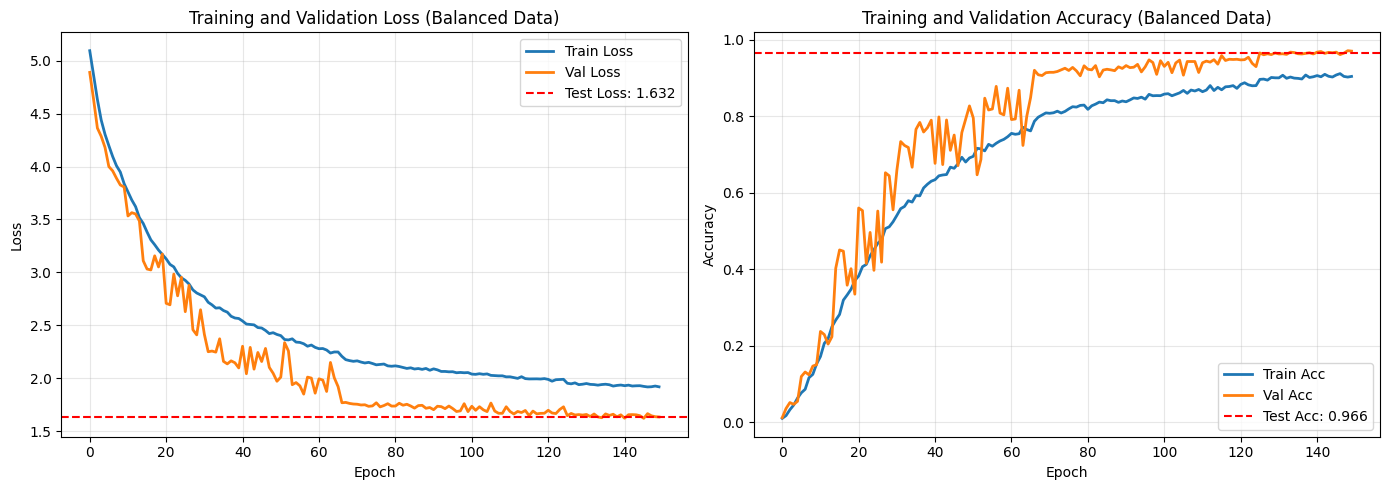

📊 Training plots saved to 'training_results_balanced.png'

✅ TRAINING COMPLETE!
🎯 Final Test Accuracy: 96.65%
🏆 Best Validation Accuracy: 97.12%


In [21]:
# ============================================================
# TCN MODEL TRAINING ON BALANCED FIXED-LENGTH DATA
# ============================================================

import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
import matplotlib.pyplot as plt

# ============================================================
# LOAD YOUR BALANCED FIXED-LENGTH DATA
# ============================================================

print("="*60)
print("📊 LOADING BALANCED FIXED-LENGTH DATA")
print("="*60)

# Check if X_balanced_fixed exists
try:
    if 'X_balanced_fixed' in globals() and 'y_balanced_fixed' in globals():
        X_data = X_balanced_fixed
        y_labels = y_balanced_fixed
        print(f"✅ Using X_balanced_fixed and y_balanced_fixed")
        print(f"   Data shape: {X_data.shape}")
        print(f"   Labels shape: {y_labels.shape}")
    else:
        # Try loading from files
        X_data = np.load('X_balanced_fixed.npy')
        y_labels = np.load('y_balanced_fixed.npy')
        print(f"✅ Loaded from files")
        print(f"   Data shape: {X_data.shape}")
        print(f"   Labels shape: {y_labels.shape}")
        
except FileNotFoundError:
    print("❌ Error: X_balanced_fixed.npy not found!")
    print("Please run the padding script first to create fixed-length data.")
    exit()
except NameError:
    print("❌ Error: X_balanced_fixed not found!")
    print("Please run the padding script first to create fixed-length data.")
    exit()

# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🔧 Using device: {DEVICE}")

# Get dimensions
FEATURE_DIM = X_data.shape[2]  # Should be 438
TARGET_FRAMES = X_data.shape[1]  # Should be fixed length (e.g., 125)
NUM_SAMPLES = X_data.shape[0]

print(f"\n📊 Data Information:")
print(f"   Feature dimension: {FEATURE_DIM}")
print(f"   Target frames: {TARGET_FRAMES}")
print(f"   Total samples: {NUM_SAMPLES:,}")

# ============================================================
# ENCODE LABELS AND CHECK CLASS DISTRIBUTION
# ============================================================

# Encode labels
le = LabelEncoder()
y_labels_encoded = le.fit_transform(y_labels)
num_classes = len(le.classes_)

print(f"\n🏷️ Label encoding complete: {num_classes} classes")

# Check class distribution
label_counts = Counter(y_labels)
print(f"\n📊 Class distribution:")
print(f"   Total classes: {num_classes}")
print(f"   Min samples per class: {min(label_counts.values())}")
print(f"   Max samples per class: {max(label_counts.values())}")
print(f"   Mean samples per class: {np.mean(list(label_counts.values())):.1f}")
print(f"   Std samples per class: {np.std(list(label_counts.values())):.1f}")

# ============================================================
# CREATE TRAIN/VAL/TEST SPLIT
# ============================================================

print(f"\n📊 Creating train/val/test splits...")

try:
    # First split: separate test set (15%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_data, y_labels_encoded,
        test_size=0.3, stratify=y_labels_encoded, random_state=42
    )
    
    # Second split: separate validation from remaining (15% of total)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5, stratify=y_temp, random_state=42
    )
    
    print(f"✅ Stratified split successful")
    
except ValueError as e:
    print(f"⚠️ Stratified split failed: {e}")
    print("   Falling back to non-stratified split...")
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_data, y_labels_encoded, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    print(f"✅ Non-stratified split completed")

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train):,} samples")
print(f"   Validation: {len(X_val):,} samples")
print(f"   Test: {len(X_test):,} samples")

# ============================================================
# CREATE MASKS (all ones since data is fixed-length and preprocessed)
# ============================================================

print(f"\n📊 Creating masks...")

# Create masks (all frames valid since data is preprocessed and fixed-length)
m_train = np.ones((len(X_train), TARGET_FRAMES), dtype=np.float32)
m_val = np.ones((len(X_val), TARGET_FRAMES), dtype=np.float32)
m_test = np.ones((len(X_test), TARGET_FRAMES), dtype=np.float32)

print(f"✅ Masks created with shape: {m_train.shape}")

# ============================================================
# DATASET CLASS
# ============================================================

class TCNBalancedDataset(Dataset):
    def __init__(self, data, masks, labels, augment=False):
        self.data = torch.from_numpy(data).float()
        self.masks = torch.from_numpy(masks).float()
        self.labels = torch.from_numpy(labels).long()
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx]
        m = self.masks[idx]
        y = self.labels[idx]
        
        # Mild augmentation for training (reduced to avoid over-augmentation)
        if self.augment:
            # Small noise
            if torch.rand(1) > 0.5:
                noise = torch.randn_like(x) * 0.003
                x = x + noise
        
        # Transpose for Conv1d (features, frames)
        x = x.transpose(0, 1)
        
        return x, m, y

# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 64  # Larger batch size for balanced data
NUM_WORKERS = 0

# Calculate class weights for balanced sampling
class_counts_train = np.bincount(y_train)
class_weights_sampler = 1.0 / (class_counts_train + 1e-6)
sample_weights = class_weights_sampler[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_dataset = TCNBalancedDataset(X_train, m_train, y_train, augment=True)
val_dataset = TCNBalancedDataset(X_val, m_val, y_val, augment=False)
test_dataset = TCNBalancedDataset(X_test, m_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================================
# OPTIMIZED TCN MODEL (Anti-overfitting)
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation, dropout=0.5):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
        )
        self.res = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        if y.size(2) != x.size(2):
            y = y[..., :x.size(2)]
        return y + self.res(x)

class TCNBalanced(nn.Module):
    def __init__(self, input_dim, num_classes, num_channels=128, num_layers=4):
        super().__init__()
        channels = [num_channels] * num_layers
        
        layers = []
        for i, c in enumerate(channels):
            in_dim = input_dim if i == 0 else channels[i-1]
            # Progressive dropout
            dropout = 0.4 if i < 2 else 0.5
            layers.append(TemporalBlock(in_dim, c, dilation=2**i, dropout=dropout))
        
        self.tcn = nn.Sequential(*layers)
        
        # Multi-layer classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(channels[-1], channels[-1] // 2),
            nn.BatchNorm1d(channels[-1] // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(channels[-1] // 2, num_classes)
        )
        
    def masked_pool(self, x, mask):
        mask = mask.unsqueeze(1)
        masked_x = x * mask
        summed = masked_x.sum(dim=2)
        valid_counts = mask.sum(dim=2).clamp(min=1)
        return summed / valid_counts
    
    def forward(self, x, mask):
        x = self.tcn(x)
        x = self.masked_pool(x, mask)
        return self.classifier(x)

# Adjust model size based on dataset size
if len(X_train) < 500:
    num_channels = 64
    num_layers = 3
    print(f"\n📐 Small dataset detected. Using smaller model: {num_layers} layers, {num_channels} channels")
elif len(X_train) < 2000:
    num_channels = 96
    num_layers = 3
    print(f"\n📐 Medium dataset detected. Using medium model: {num_layers} layers, {num_channels} channels")
else:
    num_channels = 128
    num_layers = 4
    print(f"\n📐 Large dataset detected. Using larger model: {num_layers} layers, {num_channels} channels")

# Initialize model
model = TCNBalanced(
    input_dim=FEATURE_DIM, 
    num_classes=num_classes,
    num_channels=num_channels,
    num_layers=num_layers
).to(DEVICE)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📐 MODEL ARCHITECTURE:")
print(f"   Input: {FEATURE_DIM} x {TARGET_FRAMES}")
print(f"   Architecture: TCN with {num_layers} layers, {num_channels} channels")
print(f"   Total parameters: {total_params:,}")

# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

# Compute class weights for loss
if num_classes > 1:
    class_weights_loss = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weights_loss = torch.tensor(class_weights_loss, dtype=torch.float32).to(DEVICE)
    print(f"\n⚖️ Class weights computed for {num_classes} classes")
else:
    class_weights_loss = None

class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.15, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        if n_classes == 1:
            return nn.functional.binary_cross_entropy_with_logits(logits.squeeze(), targets.float())
        
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = torch.log_softmax(logits, dim=1)
        
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
            
        return loss.mean()

# Training configuration
LR = 5e-4  # Lower learning rate
WEIGHT_DECAY = 1e-3  # Higher weight decay
EPOCHS = 150
PATIENCE = 20
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.15

criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights_loss)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8)

print(f"\n⚙️ Training Configuration:")
print(f"   Learning rate: {LR}")
print(f"   Weight decay: {WEIGHT_DECAY}")
print(f"   Label smoothing: {LABEL_SMOOTH}")
print(f"   Batch size: {BATCH_SIZE}")

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, m, y in loader:
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x, m)
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
    
    return total_loss / total, correct / total

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, m, y in loader:
            x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
            outputs = model(x, m)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y.cpu().numpy())
    
    return total_loss / total, correct / total, all_preds, all_targets

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING TRAINING ON BALANCED DATA")
print("="*60)
print(f"   Device: {DEVICE}")
print(f"   Training samples: {len(X_train):,}")
print(f"   Validation samples: {len(X_val):,}")
print(f"   Test samples: {len(X_test):,}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print("="*60)

best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    # Train
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc, _, _ = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print progress
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
        }, 'best_tcn_balanced_model.pth')
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)

# Load best model
checkpoint = torch.load('best_tcn_balanced_model.pth', map_location=torch.device(DEVICE))
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f}")

# Test evaluation
test_loss, test_acc, test_preds, test_targets = evaluate(test_loader)
print(f"\n🎯 TEST SET RESULTS:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Per-class accuracy
from sklearn.metrics import accuracy_score

per_class_acc = []
for i in range(num_classes):
    mask = np.array(test_targets) == i
    if mask.sum() > 0:
        acc = accuracy_score(np.array(test_targets)[mask], np.array(test_preds)[mask])
        per_class_acc.append(acc)

print(f"\n📊 Per-Class Performance:")
print(f"   Mean accuracy: {np.mean(per_class_acc):.4f}")
print(f"   Min accuracy: {np.min(per_class_acc):.4f}")
print(f"   Max accuracy: {np.max(per_class_acc):.4f}")
print(f"   Classes >80%: {sum(1 for a in per_class_acc if a > 0.8)}")
print(f"   Classes <50%: {sum(1 for a in per_class_acc if a < 0.5)}")

# Overfitting analysis
final_gap = train_accs[-1] - val_accs[-1] if train_accs else 0
print(f"\n📈 Overfitting Analysis:")
print(f"   Final Train Accuracy: {train_accs[-1]:.4f}")
print(f"   Final Val Accuracy: {val_accs[-1]:.4f}")
print(f"   Train-Val Gap: {final_gap:.4f}")

if final_gap < 0.1:
    print(f"   ✅ Excellent! Minimal overfitting")
elif final_gap < 0.15:
    print(f"   ✅ Good! Acceptable overfitting")
else:
    print(f"   ⚠️ Still some overfitting, consider more regularization")

# ============================================================
# SAVE RESULTS
# ============================================================

# Save label encoder
with open('label_encoder_balanced.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save training history
history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'per_class_acc': per_class_acc,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM,
    'model_params': total_params,
}

with open('training_history_balanced.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"\n💾 Saved files:")
print(f"   Model: best_tcn_balanced_model.pth")
print(f"   Label encoder: label_encoder_balanced.pkl")
print(f"   Training history: training_history_balanced.pkl")

# ============================================================
# PLOT RESULTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.3f}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss (Balanced Data)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train Acc', linewidth=2)
axes[1].plot(val_accs, label='Val Acc', linewidth=2)
axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.3f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy (Balanced Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_results_balanced.png', dpi=150)
plt.show()
print("📊 Training plots saved to 'training_results_balanced.png'")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"🎯 Final Test Accuracy: {test_acc*100:.2f}%")
print(f"🏆 Best Validation Accuracy: {best_val_acc*100:.2f}%")
print("="*60)